In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path


In [35]:


# Load data
inFileName = r"C:\Users\Franco\Desktop\Pubblicazione\05.1\segment\curvesegmentation\data\9280_score.csv"
df = pd.read_csv(inFileName)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Smoothed series (7-day centered moving average)
df["score_smooth"] = df["0"].rolling(window=7, center=True, min_periods=1).mean()

# Numeric x for geometry
x = (df["Date"] - df["Date"].min()).dt.days.to_numpy().astype(float)
y = df["score_smooth"].to_numpy().astype(float)
n = len(x)

def point_line_distance(x0, y0, x1, y1, x2, y2):
    num = abs((y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1)
    den = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    if den == 0:
        return 0.0
    return num / den

def segment_max_error(i_start, i_end):
    """Return (max_dist, max_idx) for segment [i_start, i_end]."""
    if i_end <= i_start + 1:
        return 0.0, None
    x1, y1 = x[i_start], y[i_start]
    x2, y2 = x[i_end], y[i_end]
    max_dist = -1.0
    max_idx = None
    for i in range(i_start + 1, i_end):
        d = point_line_distance(x[i], y[i], x1, y1, x2, y2)
        if d > max_dist:
            max_dist = d
            max_idx = i
    if max_idx is None or max_dist < 0:
        return 0.0, None
    return max_dist, max_idx

# Global K-segment top-down algorithm
K = 10  # desired number of segments
segments = [(0, n-1)]  # list of (start,end)

# Iteratively split the segment with largest error
while len(segments) < K:
    best_err = 0.0
    best_idx = None
    best_seg_pos = None  # index in segments list

    for pos, (i_start, i_end) in enumerate(segments):
        err, idx_max = segment_max_error(i_start, i_end)
        if err > best_err:
            best_err = err
            best_idx = idx_max
            best_seg_pos = pos

    if best_idx is None or best_err <= 0:
        break  # no more error to reduce

    # Split chosen segment at best_idx
    i_start, i_end = segments[best_seg_pos]
    new_segments = []
    # keep segments before
    new_segments.extend(segments[:best_seg_pos])
    # add two new segments
    new_segments.append((i_start, best_idx))
    new_segments.append((best_idx, i_end))
    # keep segments after
    new_segments.extend(segments[best_seg_pos+1:])
    segments = new_segments

# Sort segments by start index
segments = sorted(segments, key=lambda s: s[0])
segments, len(segments)

([(0, 8),
  (8, 13),
  (13, 17),
  (17, 36),
  (36, 43),
  (43, 59),
  (59, 74),
  (74, 101),
  (101, 151),
  (151, 174)],
 10)

C:\Users\Franco\Desktop\Pubblicazione\05.1\segment\curvesegmentation\data\9280_score.csv


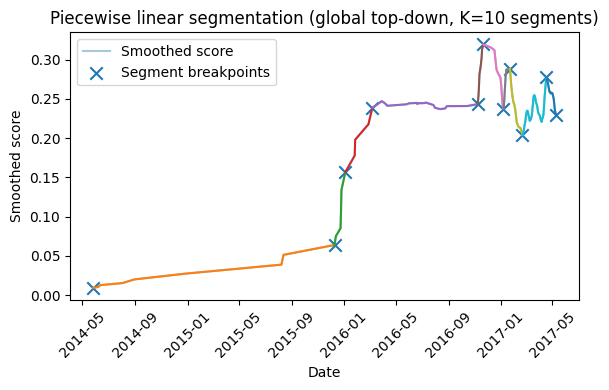

In [ ]:
# Plot smoothed curve and new global-topdown segments
plt.figure(figsize=(6, 4))

# Smoothed curve
plt.plot(df["Date"], df["score_smooth"], linestyle="-", alpha=0.4, label="Smoothed score")

# Plot each linear segment
for (i_start, i_end) in segments:
    plt.plot(df["Date"].iloc[i_start:i_end+1],
             y[i_start:i_end+1],
             linestyle="-")

# Breakpoints
break_indices = sorted(set([s[0] for s in segments] + [segments[-1][1]]))
plt.scatter(df["Date"].iloc[break_indices], y[break_indices], marker="x", s=80, label="Segment breakpoints")

plt.xlabel("Date")
plt.ylabel("Smoothed score")
plt.title("Piecewise linear segmentation (global top-down, K=10 segments)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot as a PDF file
print(inFileName)
save_path=r"C:\Users\Franco\Desktop\Pubblicazione\05.1\segment\charts_user_segmentation"
user_id = Path(inFileName).stem.split("_")[0]

plt.savefig(f"{save_path}\{user_id}_seg.pdf", format='pdf', bbox_inches='tight')
plt.show()

df_breaks = df.loc[break_indices, ["Date", "score_smooth"]]
df_breaks.to_csv(rf"C:\Users\Franco\Desktop\Pubblicazione\05.1\segment\user_breaks\{user_id}_breaks.csv", index=False)

